# Day 08. Exercise 04
# Regression

## 0. Imports

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [4]:
df = pd.read_csv("../data/checker_regression.csv")
df = df.fillna(0)
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     object 
 1   num_commits  29 non-null     int64  
 2   pageviews    29 non-null     float64
 3   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.1+ KB


In [10]:
df

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,0.000000
6,user_10,20,89.0,0.000000
12,user_11,7,0.0,-2.000000
13,user_12,86,0.0,-89.000000
14,user_13,52,0.0,-48.500000
15,user_14,61,143.0,0.000000
19,user_15,23,0.0,-17.500000
20,user_16,41,0.0,-39.333333
21,user_17,51,47.0,0.000000
27,user_18,5,3.0,0.000000


In [11]:
X = df[["num_commits", "pageviews"]]
y = df["AVG(diff)"]
X, X_test, y, y_test = train_test_split(X, y,random_state=21, test_size=0.2)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [ ]:
def crossval(n_splits, X, y):
    kf = KFold(n_splits=n_splits, random_state=21, shuffle=True)
    model = LinearRegression(fit_intercept=True)

    accuracies = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X_tr.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        mse_train = mean_squared_error(y_train, y_pred_train)
        mse_test = mean_squared_error(y_test, y_pred_test)
        accuracies.append(mse_test)

        print(f"train - {mse_train} | test - {mse_test}")

    print(f"Average RMSE on crossval is {np.mean(accuracies)}")

crossval(10, X, y)




train - 2844.4633918449135 | test - 13280.126649973216
train - 3894.998085979375 | test - 4810.544363709593
train - 4192.752120245126 | test - 2745.2799973355372
train - 4101.24325337098 | test - 6113.380266095472
train - 4041.6648833530717 | test - 3442.1166479725625
train - 4277.3621671062065 | test - 1030.4542051748826
train - 4148.133152307096 | test - 2361.301883452227
train - 3747.334093453023 | test - 6792.618252724639
train - 4185.277748121367 | test - 1919.4592260342436
train - 3944.0858533493065 | test - 4966.343517654215
Average RMSE on crossval is 4746.162501012659


In [8]:
def crossval(n_splits, X, y):
    kf = KFold(n_splits=n_splits, random_state=21, shuffle=True)
    model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=5)

    accuracies = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        mse_train = mean_squared_error(y_train, y_pred_train)
        mse_test = mean_squared_error(y_test, y_pred_test)
        accuracies.append(mse_test)

        print(f"train - {mse_train} | test - {mse_test}")

    print(f"Average RMSE on crossval is {np.mean(accuracies)}")

crossval(10, X, y)


train - 1420.7826782407406 | test - 7939.40870627572
train - 2152.9530041666667 | test - 2315.0571046296295
train - 2430.683607142857 | test - 84.62370370370374
train - 2219.2512043335846 | test - 1299.083719135802
train - 2161.4363895187707 | test - 2007.315200617284
train - 1861.1174234693879 | test - 5686.222534722224
train - 2296.3947228521038 | test - 354.0756172839507
train - 1935.2816099773245 | test - 4117.8125
train - 2277.2555187074827 | test - 588.5308680555556
train - 2130.659273116654 | test - 2384.33487654321
Average RMSE on crossval is 2677.646483096708


In [9]:
def crossval(n_splits, X, y):
    model =  RandomForestRegressor(n_estimators=150, max_depth=5, min_samples_leaf=3, min_samples_split=5)
    kf = KFold(n_splits=n_splits, random_state=21, shuffle=True)
    
    accuracies = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        mse_train = mean_squared_error(y_train, y_pred_train)
        mse_test = mean_squared_error(y_test, y_pred_test)
        accuracies.append(mse_test)

        print(f"train - {mse_train} | test - {mse_test}")

    print(f"Average RMSE on crossval is {np.mean(accuracies)}")

crossval(10, X, y)

train - 1412.5600887598678 | test - 9389.761205358764
train - 2052.203446197361 | test - 4189.241275798311
train - 2292.552877769767 | test - 69.2980245373074
train - 2158.1137162059113 | test - 2239.600016305179
train - 2210.7253380837 | test - 1840.3155948917954
train - 1826.9486440808028 | test - 4791.489148381251
train - 2273.08733207335 | test - 710.5138839516364
train - 1942.1956452370505 | test - 4109.853194626257
train - 2190.259675828423 | test - 344.3845996150664
train - 1937.758188645665 | test - 3479.5818693203623
Average RMSE on crossval is 3116.403881278593


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [13]:
model = LinearRegression(fit_intercept=True)
model.fit(X, y)

y_pred = model.predict(X_test)

res = [[y_test.iloc[i], y_pred[i]] for i in range(len(y_pred))]
res

[[-52.333333333333336, -65.37155876184866],
 [-157.4, -64.35835788426154],
 [0.0, -39.10173550195085],
 [-137.2, -64.6960915101239],
 [0.0, -19.73759138130074],
 [-39.333333333333336, -65.03382513598628]]

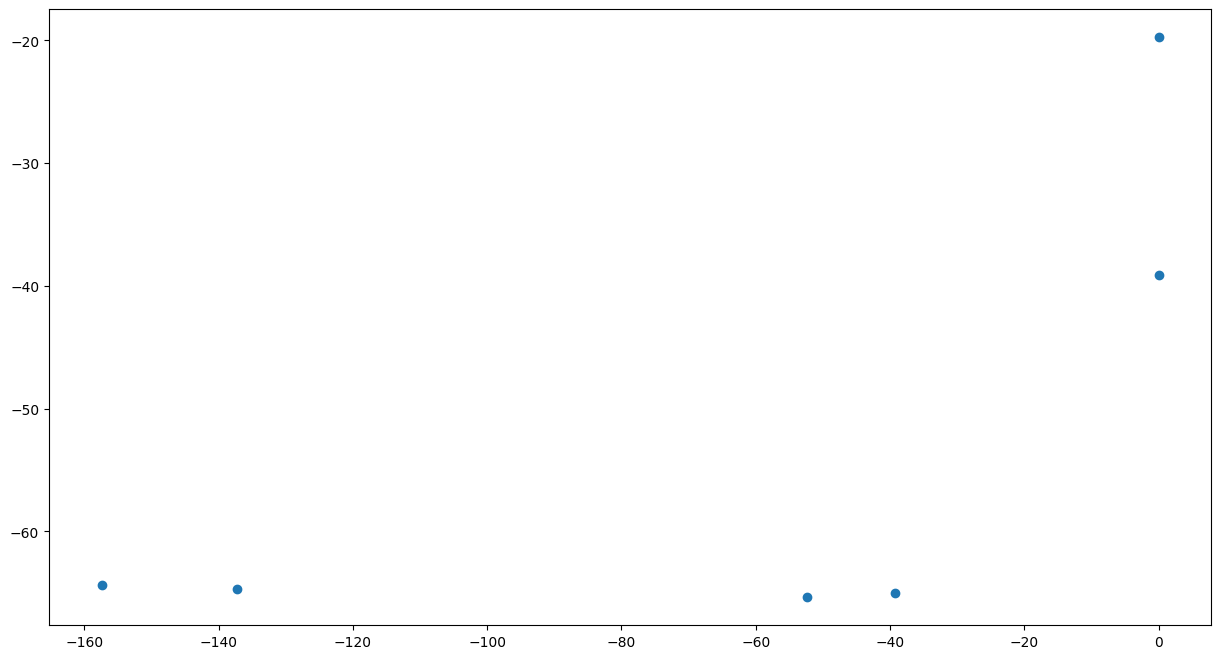

In [81]:
plt.figure(figsize=(15, 8))
plt.scatter(y_test, y_pred)
plt.show()

In [14]:
model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=5)
model.fit(X, y)

y_pred = model.predict(X_test)

res = [[y_test.iloc[i], y_pred[i]] for i in range(len(y_pred))]
res

[[-52.333333333333336, -118.40714285714286],
 [-157.4, -118.40714285714286],
 [0.0, 0.0],
 [-137.2, -118.40714285714286],
 [0.0, 0.0],
 [-39.333333333333336, -118.40714285714286]]

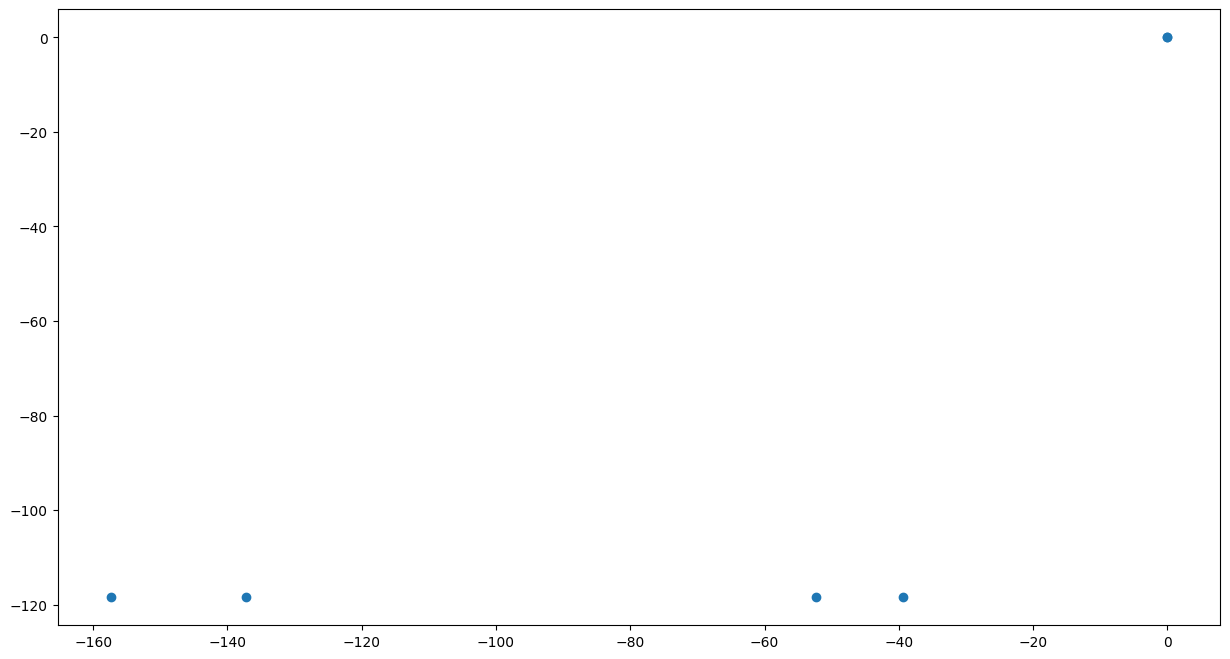

In [84]:
plt.figure(figsize=(15, 8))
plt.scatter(y_test, y_pred)
plt.show()

In [15]:
model =  RandomForestRegressor(n_estimators=150, max_depth=5, min_samples_leaf=3, min_samples_split=5)
model.fit(X, y)

y_pred = model.predict(X_test)

res = [[y_test.iloc[i], y_pred[i]] for i in range(len(y_pred))]
res

[[-52.333333333333336, -112.69292760141094],
 [-157.4, -107.73185749559082],
 [0.0, -0.18657777777777776],
 [-137.2, -113.35722760141097],
 [0.0, -0.6521234567901234],
 [-39.333333333333336, -113.54214664903002]]

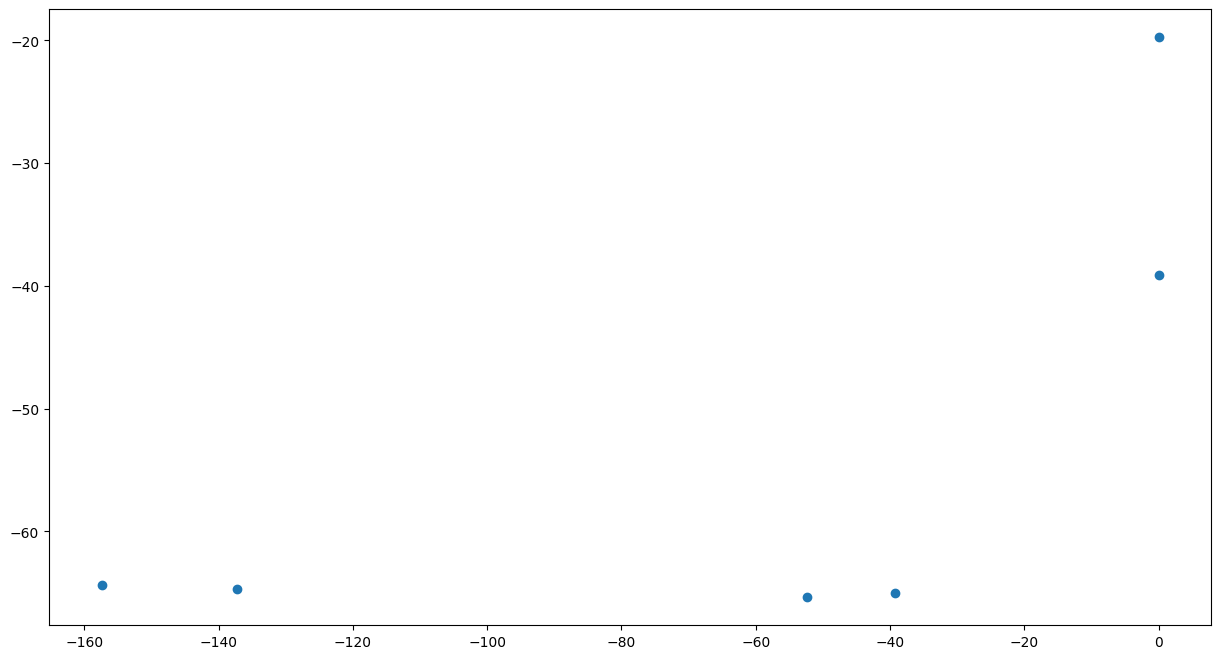

In [93]:
plt.figure(figsize=(15, 8))
plt.scatter(y_test, y_pred)
plt.show()

How would plot look like in the ideal case? как диагональ